---
## Análisis para CityScoot: de Regresión Lineal a Regresión Logística

--- 

### 1) Cargar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

### 2) Cargar datos y preparar variables

In [2]:
csv_path = Path("cityscoot_demand_logistic.csv")
df = pd.read_csv(csv_path)

display(df.head())
print(df.shape, df["high_demand"].value_counts())

,day,temp_c,rain_mm,marketing_spend,price_per_min,is_weekend,is_holiday,city_event,demand,high_demand
0,1,23.0,1.4,0,0.25,0,0,0,997.0,0
1,2,19.2,3.9,1000,0.15,1,0,0,2137.0,1
2,3,23.9,3.1,0,0.20,0,1,0,1532.0,1
3,4,29.1,3.4,200,0.20,1,0,0,1802.0,1
4,5,18.6,0.1,0,0.25,0,0,0,1065.0,0


(365, 10) high_demand
1    274
0     91
Name: count, dtype: int64


### 3) Selección de features
Usamos un conjunto compacto de predictores y escalamos las variables:
- temp_c
- rain_mm
- marketing_spend
- price_per_min
- is_weekend
- is_holiday
- city_event

In [ ]:
features = [
    "temp_c",
    "rain_mm",
    "marketing_spend",
    "price_per_min",
    "is_weekend",
    "is_holiday",
    "city_event"
]

# Defino X e y, divido en train y test, y escalo los datos
X = df[features].copy().values.astype(float)
y = df["high_demand"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### 4) Train/Test split + Escalado

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### 🔴 5) Intento con Regresión Lineal sobre objetivo binario.
### Ajustamos regresión lineal como si el target fuera continuo.

In [16]:
lin = LinearRegression()
lin.fit(X_train_sc, y_train)

y_pred_lin_cont = lin.predict(X_test_sc)  # valores reales, no probabilidades

mse_lin = mean_squared_error(y_test, y_pred_lin_cont)
r2_lin = r2_score(y_test, y_pred_lin_cont)

print(f"MSE (lineal sobre binario): {mse_lin:.4f}")
print(f"R2 (lineal sobre binario): {r2_lin:.4f}")

print(
    "Rango de predicciones lineales (deberían ser probabilidades entre 0 y 1 y no lo son):",
    round(float(y_pred_lin_cont.min()), 3),
    "->",
    round(float(y_pred_lin_cont.max()), 3)
)

MSE (lineal sobre binario): 0.1112
R2 (lineal sobre binario): 0.4069
Rango de predicciones lineales (deberían ser probabilidades entre 0 y 1 y no lo son): 0.064 -> 1.595


#### Forzamos umbral 0.5 para clasificar

In [17]:
y_pred_lin_cls = (y_pred_lin_cont >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_lin_cls)

print(f"Accuracy lineal con umbral 0.5: {acc_lin:.3f}")

Accuracy lineal con umbral 0.5: 0.924


### 6) Regresión Logística – Modelo correcto para clasificación

---
##### Recordando algunos conceptos...

a. Combinación lineal: z = β0 + Σ βi xi

b. Sigmoide: σ(z) = 1 / (1 + e^(-z))   → p ∈ (0, 1) --- Me da una probabilidad a partir del valor z

c. Cálculo de log-odds (logit): log(p/(1-p)) = z

---

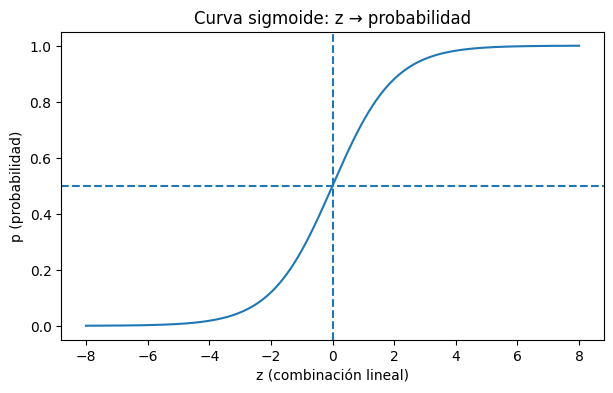

In [26]:
# Funciones auxiliares
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def odds_from_p(p):
    return p / (1 - p)

def p_from_odds(odds):
    return odds / (1 + odds)

# De z a probabilidad p con la sigmoide
z_vals = np.linspace(-8, 8, 400)
p_vals = sigmoid(z_vals)

plt.figure(figsize=(7, 4))
plt.plot(z_vals, p_vals)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z (combinación lineal)")
plt.ylabel("p (probabilidad)")
plt.title("Curva sigmoide: z → probabilidad")
plt.show()

In [27]:
# Escenarios CityScoot (z, odds, log-odds, p)
# Usamos una combinación lineal ilustrativa (no entrenada)
# z = -2.5 + 0.12*temp_c - 0.06*rain_mm + 0.0015*marketing + 1.0*is_weekend

scenarios = pd.DataFrame([
    {
        "name": "A - Lluvioso y frío, sin marketing",
        "temp_c": 15,
        "rain_mm": 12,
        "marketing": 0,
        "is_weekend": 0
    },
    {
        "name": "B - Templado, poca lluvia, marketing medio",
        "temp_c": 22,
        "rain_mm": 2,
        "marketing": 500,
        "is_weekend": 0
    },
    {
        "name": "C - Soleado, seco, marketing alto",
        "temp_c": 28,
        "rain_mm": 0,
        "marketing": 1000,
        "is_weekend": 1
    }
])

# Coeficientes ilustrativos
b0 = -2.5
b_temp = 0.12
b_rain = -0.06
b_marketing = 0.0015
b_weekend = 1.0

def compute_row(row):
    z = (
        b0
        + b_temp * row["temp_c"]
        + b_rain * row["rain_mm"]
        + b_marketing * row["marketing"]
        + b_weekend * row["is_weekend"]
    )
    p = sigmoid(z)
    odds = odds_from_p(p)
    log_odds = np.log(odds)
    return pd.Series({
        "z": z,
        "p": p,
        "odds": odds,
        "log_odds": log_odds
    })

scenarios_calc = scenarios.apply(compute_row, axis=1)
scenarios_out = pd.concat([scenarios, scenarios_calc], axis=1)

scenarios_out.round(3)

,name,temp_c,rain_mm,marketing,is_weekend,z,p,odds,log_odds
0,"A - Lluvioso y frío, sin marketing",15,12,0,0,-1.42,0.195,0.242,-1.42
1,"B - Templado, poca lluvia, marketing medio",22,2,500,0,0.77,0.684,2.160,0.77
2,"C - Soleado, seco, marketing alto",28,0,1000,1,3.36,0.966,28.789,3.36


In [21]:
logreg = LogisticRegression(
    max_iter=200,
    solver="lbfgs"
)

logreg.fit(X_train_sc, y_train)

# Probabilidades y clases
y_proba = logreg.predict_proba(X_test_sc)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Métricas de clasificación
ll = log_loss(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Log-loss: {ll:.4f}")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"ROC AUC: {auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Log-loss: 0.2129
Accuracy: 0.935
Precision: 0.944
Recall: 0.971
ROC AUC: 0.972
Confusion matrix:
 [[19  4]
 [ 2 67]]


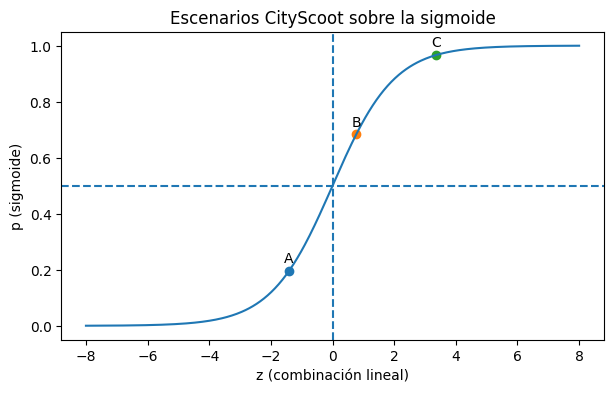

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(z_vals, p_vals)

for _, row in scenarios_out.iterrows():
    plt.scatter(row["z"], row["p"])
    plt.text(
        row["z"],
        row["p"] + 0.03,
        row["name"].split(" - ")[0],
        ha="center"
    )

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z (combinación lineal)")
plt.ylabel("p (sigmoide)")
plt.title("Escenarios CityScoot sobre la sigmoide")
plt.show()

### 7) Curva ROC

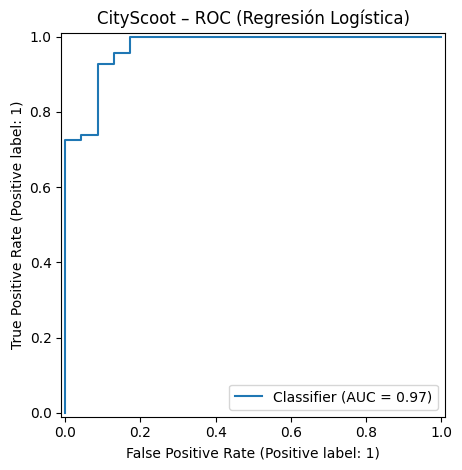

In [22]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("CityScoot – ROC (Regresión Logística)")
plt.tight_layout()
plt.show()

### 8) Comparación de funciones de costo: MSE vs Log-loss

In [23]:
mse_lin_on_test = mean_squared_error(y_test, y_pred_lin_cont)
ll_log_on_test = log_loss(y_test, y_proba)

print(f"MSE (lineal): {mse_lin_on_test:.4f}")
print(f"Log-loss (logística): {ll_log_on_test:.4f}")

MSE (lineal): 0.1112
Log-loss (logística): 0.2129


### 9) Interpretación: coeficientes y odds ratio

In [30]:
coef = logreg.coef_.ravel()
intercept = logreg.intercept_[0]

odds_ratio = np.exp(coef)

coef_df = pd.DataFrame({
    "feature": features,
    "coef_logit": coef,
    "odds_ratio": odds_ratio
}).sort_values(by="odds_ratio", ascending=False)

print(f"Intercepto (logit): {intercept:.3f}")

display(coef_df)

Intercepto (logit): 2.533


,feature,coef_logit,odds_ratio
2,marketing_spend,2.061442,7.857289
0,temp_c,1.399847,4.054579
6,city_event,1.138013,3.120561
4,is_weekend,0.817153,2.264045
5,is_holiday,0.795742,2.216086
3,price_per_min,-0.287254,0.750321
1,rain_mm,-0.428285,0.651626


---

#### → La regresión lineal:
- Optimiza MSE (incorrecto para clasificación)
- Puede predecir valores fuera de [0,1]
- No modela probabilidades

#### → La regresión logística

- Produce probabilidades válidas
- Optimiza log-loss
- Permite interpretación vía odds ratio
- Es coherente con clasificación binaria

---